# 📊 Social Media Intelligence & Sentiment Analysis: US–Iran Geopolitical Discourse on Twitter/X
> **Portfolio Project:** Automated OSINT Text Mining, NLP Preprocessing, Lexical Topic Extraction & VADER Sentiment Classification  
> **Dataset:** `data/raw/datasetWW3.csv` (5,345 Raw Scraped Tweets)  
> **Output:** `data/processed/clean_ww3_sentiment.csv`  

---
### Pipeline Highlights:
1. **Data Ingestion & DOM Standardization**: Ingest unstructured Twitter/X dynamic scrape records.
2. **Linguistic Preprocessing & Entity Safeguard**: Custom regex rule protecting 'US' entity before case-folding, URL/mention stripping, and ASCII cleaning.
3. **Tokenization & Lemmatization**: WordNet POS-aware normalization.
4. **Lexical Frequency & Word Cloud**: Extracting dominant geopolitical discourse (war, peace, military expenditure, rhetoric).
5. **VADER Sentiment Scoring**: Quantifying polarity across polarized public narratives.
6. **Strategic Insights & Intelligence Takeaways**: Highlighting public perception on conflict escalation.

In [1]:
# ── 1. Import Library ──
import pandas as pd
import numpy as np
import re
import string
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


In [ ]:
# ── 2. Load Data ──
FILE_PATH = 'data/raw/datasetWW3.csv'  # Sesuaikan path jika perlu

df_raw = pd.read_csv(FILE_PATH)
print(f'📦 Shape data mentah : {df_raw.shape}')
print(f'📋 Kolom             : {df_raw.columns.tolist()}')
df_raw.head(3)

📦 Shape data mentah : (5345, 12)
📋 Kolom             : ['css-175oi2r href', 'css-9pa8cd src', 'css-1jxf684', 'css-1jxf684 2', 'css-1jxf684 3', 'css-146c3p1', 'css-1jxf684 4', 'css-1jxf684 5', 'css-1jxf684 6', 'css-1jxf684 7', 'css-146c3p1 href', 'css-175oi2r href 4']


,css-175oi2r href,css-9pa8cd src,css-1jxf684,css-1jxf684 2,css-1jxf684 3,css-146c3p1,css-1jxf684 4,css-1jxf684 5,css-1jxf684 6,css-1jxf684 7,css-146c3p1 href,css-175oi2r href 4
0,https://x.com/ProudSocialist,https://pbs.twimg.com/profile_images/1712129275879407616/UehnD0bo_normal.jpg,Power to the People ☭,@ProudSocialist,Follow,Click to Follow ProudSocialist,"Rubio: “Imagine if instead of spending billions on weapons, Iran spent that money on its people. They’d have a much ...",0:13,"5:22 AM · Mar 31, 2026",·,https://x.com/ProudSocialist/status/2038728611889328346/analytics,https://x.com/HororPotong
1,https://x.com/noodleandeggrol,https://pbs.twimg.com/profile_images/1418053089244848129/OIx_BnYW_normal.jpg,H** S**,@noodleandeggrol,·,18h,"Not sure if he's really that stupid, or is this some psychological operation.",20,29,1.1K,https://x.com/noodleandeggrol/status/2038729312405520798,https://x.com/noodleandeggrol/status/2038729312405520798/analytics
2,https://x.com/ProudSocialist,https://pbs.twimg.com/profile_images/1712129275879407616/UehnD0bo_normal.jpg,Power to the People ☭,@ProudSocialist,·,18h,Oh they know what they are doing. They are blatantly spitting in our faces.,8,24,788,https://x.com/ProudSocialist/status/2038729527040360519,https://x.com/ProudSocialist/status/2038729527040360519/analytics


In [3]:
# ── 3. Tokenizing ──
import re, string

def tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [t.strip() for t in text.split() if len(t.strip()) > 2]
    return tokens

df_raw['tokens'] = df_raw['css-1jxf684 4'].apply(tokenize)

print(f"✅ Tokenisasi selesai.")
print(f"Total baris      : {len(df_raw):,}")
print(f"Rata-rata token  : {df_raw['tokens'].apply(len).mean():.1f} token/tweet")
print()
print("--- Contoh hasil tokenisasi ---")
for i in range(3):
    print(f"[ASLI]   : {df_raw['css-1jxf684 4'].iloc[i]}")
    print(f"[TOKENS] : {df_raw['tokens'].iloc[i]}")
    print()

✅ Tokenisasi selesai.
Total baris      : 5,345
Rata-rata token  : 11.6 token/tweet

--- Contoh hasil tokenisasi ---
[ASLI]   : Rubio: “Imagine if instead of spending billions on weapons, Iran spent that money on its people. They’d have a much different country.”

Imagine if instead of spending TRILLIONS on war the US spent that money on its people. We’d have a better country & the world would have peace.
[TOKENS] : ['rubio', 'imagine', 'instead', 'spending', 'billions', 'weapons', 'iran', 'spent', 'that', 'money', 'its', 'people', 'theyd', 'have', 'much', 'different', 'country', 'imagine', 'instead', 'spending', 'trillions', 'war', 'the', 'spent', 'that', 'money', 'its', 'people', 'wed', 'have', 'better', 'country', 'the', 'world', 'would', 'have', 'peace']

[ASLI]   : Not sure if he's really that stupid, or is this some psychological operation.
[TOKENS] : ['not', 'sure', 'hes', 'really', 'that', 'stupid', 'this', 'some', 'psychological', 'operation']

[ASLI]   : Oh they know what they

In [4]:
# ── Pra-proses: Lindungi "US" (United States) sebelum Case Folding ──
import re

def protect_us_entity(text):
    if not isinstance(text, str):
        return text

    # Pola: 'US' diikuti kata yang mengindikasikan negara
    context_after = (
        r'\bUS\b(?=\s+(military|government|forces|troops|army|navy|soldiers|'
        r'president|congress|senate|sanctions|policy|dollar|attack|strike|'
        r'war|admin|officials|embassy|intelligence|foreign|allies|nato))'
    )
    text = re.sub(context_after, '__UNITED_STATES__', text)

    # Pola: diawali kata tertentu + spasi + 'US' (lookbehind diganti jadi full match + group)
    context_before = r'\b(the|in|of|by|from|against|with|to)\s+US\b'
    text = re.sub(context_before, lambda m: m.group(1) + ' __UNITED_STATES__', text)

    # Sisa 'US' kapital semua yang belum tertangkap → anggap negara
    text = re.sub(r'\bUS\b', '__UNITED_STATES__', text)

    #text = re.sub(r'Un' )
    return text

def restore_us_entity(text):
    if not isinstance(text, str):
        return text
    return text.replace('__united_states__', 'united_states') \
               .replace('__UNITED_STATES__', 'united_states')

# ── Terapkan SEBELUM pipeline preprocessing ──
df_raw['protected_text'] = df_raw['css-1jxf684 4'].apply(protect_us_entity)

print("✅ Proteksi entitas 'US' selesai.")
print()
print("--- Contoh identifikasi 'US' ---")
sample = df_raw[df_raw['css-1jxf684 4'].str.contains(r'\bUS\b', na=False)].head(5)
for _, row in sample.iterrows():
    print(f"[ASLI]      : {row['css-1jxf684 4']}")
    print(f"[PROTECTED] : {row['protected_text']}")
    print()

✅ Proteksi entitas 'US' selesai.

--- Contoh identifikasi 'US' ---
[ASLI]      : Rubio: “Imagine if instead of spending billions on weapons, Iran spent that money on its people. They’d have a much different country.”

Imagine if instead of spending TRILLIONS on war the US spent that money on its people. We’d have a better country & the world would have peace.
[PROTECTED] : Rubio: “Imagine if instead of spending billions on weapons, Iran spent that money on its people. They’d have a much different country.”

Imagine if instead of spending TRILLIONS on war the __UNITED_STATES__ spent that money on its people. We’d have a better country & the world would have peace.

[ASLI]      : Rubio: “Imagine if instead of spending billions on weapons, Iran spent that money on its people. They’d have a much different country.”

Imagine if instead of spending TRILLIONS on war the US spent that money on its people. We’d have a better country & the world would have peace.
[PROTECTED] : Rubio: “Imagine if

In [5]:
# ── Case Folding ──
df_raw['case_folded'] = df_raw['protected_text'].str.lower()

print("✅ Case folding selesai.")
print()
print("--- Contoh hasil case folding ---")
for i in range(3):
    print(f"[ASLI]  : {df_raw['protected_text'].iloc[i]}")
    print(f"[LOWER] : {df_raw['case_folded'].iloc[i]}")
    print()

✅ Case folding selesai.

--- Contoh hasil case folding ---
[ASLI]  : Rubio: “Imagine if instead of spending billions on weapons, Iran spent that money on its people. They’d have a much different country.”

Imagine if instead of spending TRILLIONS on war the __UNITED_STATES__ spent that money on its people. We’d have a better country & the world would have peace.
[LOWER] : rubio: “imagine if instead of spending billions on weapons, iran spent that money on its people. they’d have a much different country.”

imagine if instead of spending trillions on war the __united_states__ spent that money on its people. we’d have a better country & the world would have peace.

[ASLI]  : Not sure if he's really that stupid, or is this some psychological operation.
[LOWER] : not sure if he's really that stupid, or is this some psychological operation.

[ASLI]  : Oh they know what they are doing. They are blatantly spitting in our faces.
[LOWER] : oh they know what they are doing. they are blatantly sp

In [17]:
# ── Text Cleaning (Regex) ──
import re

def usclean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'\bunited|states\b', '__united_states__', text) # sambung kata
    text = re.sub(r'\bu.s.\b', '__united_states__', text) # U.S.
    return text

df_raw['usclean_text'] = df_raw['case_folded'].apply(usclean_text)

print("✅ Text cleaning selesai.")
print()
print("--- Contoh hasil cleaning ---")
for i in range(3):
    print(f"[SEBELUM] : {df_raw['case_folded'].iloc[i]}")
    print(f"[SESUDAH] : {df_raw['usclean_text'].iloc[i]}")
    print()

✅ Text cleaning selesai.

--- Contoh hasil cleaning ---
[SEBELUM] : rubio: “imagine if instead of spending billions on weapons, iran spent that money on its people. they’d have a much different country.”

imagine if instead of spending trillions on war the __united_states__ spent that money on its people. we’d have a better country & the world would have peace.
[SESUDAH] : rubio: “imagine if instead of spending billions on weapons, iran spent that money on its people. they’d have a much different country.”

imagine if instead of spending trillions on war the __united_states__ spent that money on its people. we’d have a better country & the world would have peace.

[SEBELUM] : not sure if he's really that stupid, or is this some psychological operation.
[SESUDAH] : not sure if he's really that stupid, or is this some psychological operation.

[SEBELUM] : oh they know what they are doing. they are blatantly spitting in our faces.
[SESUDAH] : oh they know what they are doing. they are bla

In [18]:
# ── Text Cleaning (Regex) ──
import re

def clean_text(text):
    if not isinstance(text, str):
        return ''
    
    text = re.sub(r'http\S+|www\.\S+', '', text)   # Hapus URL
    text = re.sub(r'@\w+', '', text)                # Hapus mention
    text = re.sub(r'#(\w+)', r'\1', text)           # Hapus simbol hashtag
    text = re.sub(r'[^\x00-\x7F]+', '', text)       # Hapus non-ASCII (emoji)
    text = re.sub(r'\d+', '', text)                  # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)              # Hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()         # Hapus spasi berlebih
    return text

df_raw['clean_text'] = df_raw['usclean_text'].apply(clean_text)

print("✅ Text cleaning selesai.")
print()
print("--- Contoh hasil cleaning ---")
for i in range(3):
    print(f"[SEBELUM] : {df_raw['usclean_text'].iloc[i]}")
    print(f"[SESUDAH] : {df_raw['clean_text'].iloc[i]}")
    print()

✅ Text cleaning selesai.

--- Contoh hasil cleaning ---
[SEBELUM] : rubio: “imagine if instead of spending billions on weapons, iran spent that money on its people. they’d have a much different country.”

imagine if instead of spending trillions on war the __united_states__ spent that money on its people. we’d have a better country & the world would have peace.
[SESUDAH] : rubio imagine if instead of spending billions on weapons iran spent that money on its people theyd have a much different country imagine if instead of spending trillions on war the __united_states__ spent that money on its people wed have a better country the world would have peace

[SEBELUM] : not sure if he's really that stupid, or is this some psychological operation.
[SESUDAH] : not sure if hes really that stupid or is this some psychological operation

[SEBELUM] : oh they know what they are doing. they are blatantly spitting in our faces.
[SESUDAH] : oh they know what they are doing they are blatantly spitting i

In [19]:
tahap = {
    'clean_text'       : 'Setelah Text Cleaning'
}

target_words = ['u', 'us', 'u.s.','__united_states__']

print("=" * 65)
print("  FREKUENSI KATA 'u' DAN 'us' PER TAHAP PIPELINE")
print("=" * 65)
print(f"\n{'Tahap':<30} {'Kata':>6} {'Frekuensi':>12} {'Jumlah Tweet':>14}")
print("-" * 65)

hasil = []
for col, label in tahap.items():
    all_words = ' '.join(df_raw[col].dropna()).split()
    freq = Counter(all_words)
    for word in target_words:
        count     = freq.get(word, 0)
        n_tweet   = df_raw[col].apply(
            lambda x: bool(re.search(rf'\b{word}\b', x)) if isinstance(x, str) else False
        ).sum()
        print(f"{label:<30} {word:>6} {count:>12,} {n_tweet:>14,}")
        hasil.append({'tahap': label, 'kata': word, 'frekuensi': count, 'jumlah_tweet': n_tweet})
    print()

  FREKUENSI KATA 'u' DAN 'us' PER TAHAP PIPELINE

Tahap                            Kata    Frekuensi   Jumlah Tweet
-----------------------------------------------------------------
Setelah Text Cleaning               u           11             11
Setelah Text Cleaning              us          191            180
Setelah Text Cleaning            u.s.            0              2
Setelah Text Cleaning          __united_states__          306            236



In [20]:
# ── Normalisasi Teks ──

slang_dict = {
    'u'     : 'you',
    'r'     : 'are',
    'ur'    : 'your',
    'n'     : 'and',
    'b4'    : 'before',
    'bc'    : 'because',
    'bcs'   : 'because',
    'cuz'   : 'because',
    'cause' : 'because',
    'w/'    : 'with',
    'w/o'   : 'without',
    'govt'  : 'government',
    'gov'   : 'government',
    'pls'   : 'please',
    'plz'   : 'please',
    'ppl'   : 'people',
    'thru'  : 'through',
    'tho'   : 'though',
    'tbh'   : 'to be honest',
    'imo'   : 'in my opinion',
    'imho'  : 'in my humble opinion',
    'omg'   : 'oh my god',
    'wtf'   : 'what the hell',
    'lol'   : 'laugh out loud',
    'smh'   : 'shaking my head',
    'ngl'   : 'not gonna lie',
    'idk'   : 'i do not know',
    'irl'   : 'in real life',
    'asap'  : 'as soon as possible',
    'rn'    : 'right now',
    'atm'   : 'at the moment',
    'fyi'   : 'for your information',
    'aka'   : 'also known as',
    'vs'    : 'versus',
    'amp'   : '',
    'rt'    : '',
}

def normalize_text(text):
    if not isinstance(text, str):
        return ''
    tokens = text.split()
    tokens = [slang_dict.get(word, word) for word in tokens]
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_raw['normalized_text'] = df_raw['clean_text'].apply(normalize_text)

print("✅ Normalisasi teks selesai.")
print()
print("--- Contoh hasil normalisasi ---")
for i in range(3):
    print(f"[SEBELUM] : {df_raw['clean_text'].iloc[i]}")
    print(f"[SESUDAH] : {df_raw['normalized_text'].iloc[i]}")
    print()

✅ Normalisasi teks selesai.

--- Contoh hasil normalisasi ---
[SEBELUM] : rubio imagine if instead of spending billions on weapons iran spent that money on its people theyd have a much different country imagine if instead of spending trillions on war the __united_states__ spent that money on its people wed have a better country the world would have peace
[SESUDAH] : rubio imagine if instead of spending billions on weapons iran spent that money on its people theyd have a much different country imagine if instead of spending trillions on war the __united_states__ spent that money on its people wed have a better country the world would have peace

[SEBELUM] : not sure if hes really that stupid or is this some psychological operation
[SESUDAH] : not sure if hes really that stupid or is this some psychological operation

[SEBELUM] : oh they know what they are doing they are blatantly spitting in our faces
[SESUDAH] : oh they know what they are doing they are blatantly spitting in our faces


In [21]:
# ── Stopword Removal (NLTK) ──
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if not isinstance(text, str):
        return ''
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df_raw['stopword_removed'] = df_raw['normalized_text'].apply(remove_stopwords)

# ── Cek Jumlah Kata Sebelum & Sesudah ──
df_raw['word_count_before'] = df_raw['normalized_text'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df_raw['word_count_after']  = df_raw['stopword_removed'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df_raw['word_removed']      = df_raw['word_count_before'] - df_raw['word_count_after']

total_before  = df_raw['word_count_before'].sum()
total_after   = df_raw['word_count_after'].sum()
total_removed = df_raw['word_removed'].sum()

print("✅ Stopword removal selesai.")
print(f"Total stopword NLTK      : {len(stop_words)}")
print()
print("--- Statistik Jumlah Kata ---")
print(f"Total kata sebelum       : {total_before:,}")
print(f"Total kata sesudah       : {total_after:,}")
print(f"Total kata dihapus       : {total_removed:,} ({total_removed/total_before*100:.1f}%)")
print(f"Rata-rata kata sebelum   : {df_raw['word_count_before'].mean():.1f} kata/tweet")
print(f"Rata-rata kata sesudah   : {df_raw['word_count_after'].mean():.1f} kata/tweet")
print()
print("--- Contoh hasil stopword removal ---")
for i in range(3):
    print(f"[SEBELUM] ({df_raw['word_count_before'].iloc[i]} kata) : {df_raw['normalized_text'].iloc[i]}")
    print(f"[SESUDAH] ({df_raw['word_count_after'].iloc[i]} kata)  : {df_raw['stopword_removed'].iloc[i]}")
    print()

✅ Stopword removal selesai.
Total stopword NLTK      : 198

--- Statistik Jumlah Kata ---
Total kata sebelum       : 76,578
Total kata sesudah       : 42,040
Total kata dihapus       : 34,538 (45.1%)
Rata-rata kata sebelum   : 14.3 kata/tweet
Rata-rata kata sesudah   : 7.9 kata/tweet

--- Contoh hasil stopword removal ---
[SEBELUM] (48 kata) : rubio imagine if instead of spending billions on weapons iran spent that money on its people theyd have a much different country imagine if instead of spending trillions on war the __united_states__ spent that money on its people wed have a better country the world would have peace
[SESUDAH] (29 kata)  : rubio imagine instead spending billions weapons iran spent money people theyd much different country imagine instead spending trillions war __united_states__ spent money people wed better country world would peace

[SEBELUM] (13 kata) : not sure if hes really that stupid or is this some psychological operation
[SESUDAH] (6 kata)  : sure hes reall

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fachl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# ── Lemmatization — NLTK WordNetLemmatizer vs spaCy ──
import nltk
#nltk.download('wordnet')
#nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
import spacy

#spacy.cli.download("en_core_web_sm")

nlp        = spacy.load('en_core_web_sm')
lemmatizer = WordNetLemmatizer()

def nltk_lemmatize_safe(text):
    if not isinstance(text, str):
        return ''
    tokens = text.split()
    result = ' '.join([lemmatizer.lemmatize(word) for word in tokens])
    return restore_us_entity(result)

def spacy_lemmatize(text):
    if not isinstance(text, str):
        return ''
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

df_raw['nltk_lemmatized']  = df_raw['stopword_removed'].apply(nltk_lemmatize_safe)
df_raw['spacy_lemmatized'] = df_raw['stopword_removed'].apply(spacy_lemmatize)

print("✅ Lemmatization selesai.")
print()
print("=" * 75)
print("  PERBANDINGAN: NLTK Lemmatizer vs spaCy Lemmatizer")
print("=" * 75)
for i in range(5):
    print(f"\n[Tweet {i+1}]")
    print(f"  SEBELUM          : {df_raw['stopword_removed'].iloc[i]}")
    print(f"  NLTK Lemmatizer  : {df_raw['nltk_lemmatized'].iloc[i]}")
    print(f"  spaCy Lemmatizer : {df_raw['spacy_lemmatized'].iloc[i]}")

# ── Verifikasi proteksi US ──
print()
print("=" * 75)
print("  VERIFIKASI PROTEKSI ENTITAS 'united_states'")
print("=" * 75)
sample = df_raw[df_raw['nltk_lemmatized'].str.contains('united_states', na=False)].head(3)
if len(sample) > 0:
    for _, row in sample.iterrows():
        print(f"  [ASLI]       : {row['css-1jxf684 4']}")
        print(f"  [LEMMATIZED] : {row['nltk_lemmatized']}")
        print()
else:
    print("  Tidak ditemukan entitas 'united_states' — cek cell protect_us_entity.")

✅ Lemmatization selesai.

  PERBANDINGAN: NLTK Lemmatizer vs spaCy Lemmatizer

[Tweet 1]
  SEBELUM          : rubio imagine instead spending billions weapons iran spent money people theyd much different country imagine instead spending trillions war __united_states__ spent money people wed better country world would peace
  NLTK Lemmatizer  : rubio imagine instead spending billion weapon iran spent money people theyd much different country imagine instead spending trillion war united_states spent money people wed better country world would peace
  spaCy Lemmatizer : rubio imagine instead spend billion weapon iran spend money people they d much different country imagine instead spend trillion war _ _ united_states _ _ spend money people we d well country world would peace

[Tweet 2]
  SEBELUM          : sure hes really stupid psychological operation
  NLTK Lemmatizer  : sure he really stupid psychological operation
  spaCy Lemmatizer : sure he s really stupid psychological operation

[T

✅ BoW berhasil dibuat.

--- Cek entitas 'united_states' di setiap BoW ---
  NLTK Lemmatizer  : 306x
  spaCy Lemmatizer : 306x



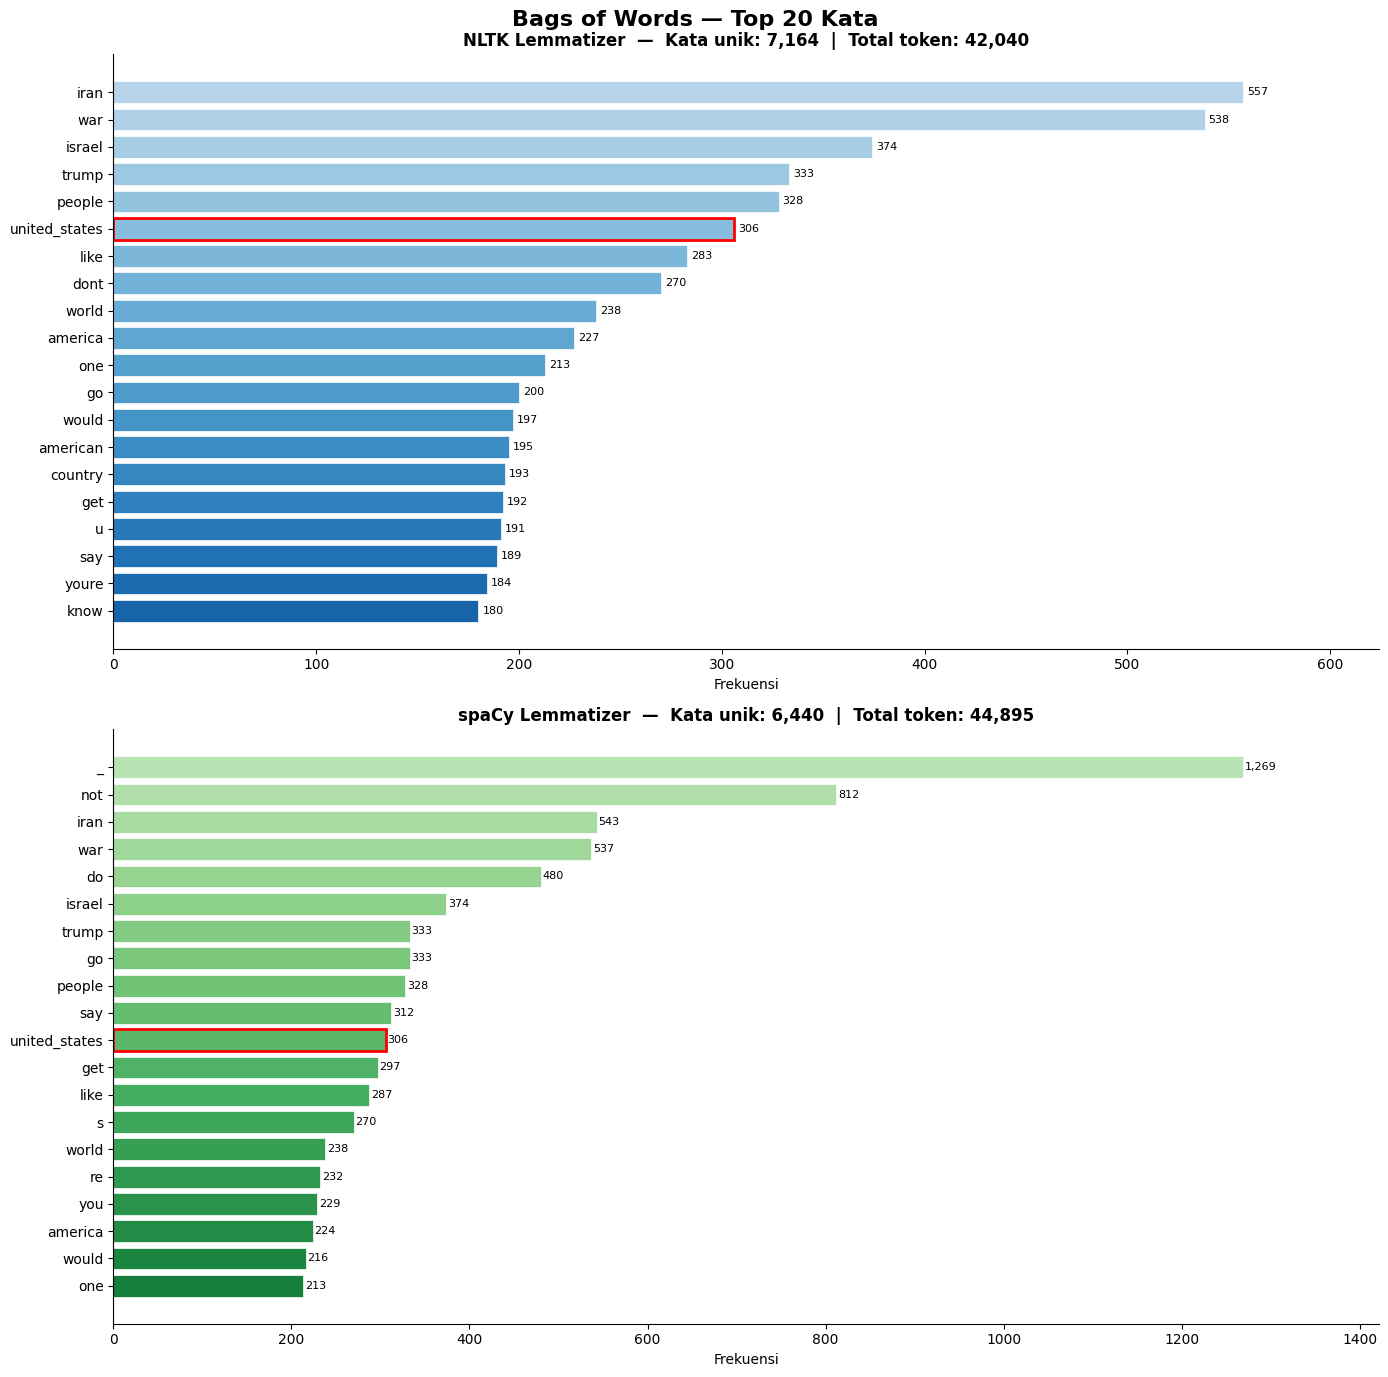

  RINGKASAN BAGS OF WORDS
Method                  Kata Unik  Total Token
----------------------------------------------------------
NLTK Lemmatizer             7,164       42,040
spaCy Lemmatizer            6,440       44,895


In [23]:
# ── Bags of Words (BoW) — NLTK Lemmatizer & spaCy Lemmatizer ──
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

TOP_N = 20

def get_bow(column):
    all_words = ' '.join(df_raw[column].dropna()).split()
    return Counter(all_words)

bow_nltk_lemma  = get_bow('nltk_lemmatized')
bow_spacy_lemma = get_bow('spacy_lemmatized')

# ── Verifikasi 'united_states' masuk BoW ──
print("✅ BoW berhasil dibuat.")
print()
print("--- Cek entitas 'united_states' di setiap BoW ---")
print(f"  NLTK Lemmatizer  : {bow_nltk_lemma.get('united_states', 0):,}x")
print(f"  spaCy Lemmatizer : {bow_spacy_lemma.get('united_states', 0):,}x")
print()

# ── Visualisasi ──
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle(f'Bags of Words — Top {TOP_N} Kata', fontsize=16, fontweight='bold')

datasets = [
    (bow_nltk_lemma,  'NLTK Lemmatizer',  plt.cm.Blues_r),
    (bow_spacy_lemma, 'spaCy Lemmatizer', plt.cm.Greens_r),
]

for ax, (bow, title, cmap) in zip(axes, datasets):
    top    = bow.most_common(TOP_N)
    words  = [w for w, _ in top]
    counts = [c for _, c in top]
    colors = cmap(np.linspace(0.2, 0.7, TOP_N))

    bars = ax.barh(words[::-1], counts[::-1], color=colors, edgecolor='white', linewidth=0.5)

    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', ha='left', fontsize=8)

    # Tandai 'united_states' jika masuk top N
    if 'united_states' in words:
        idx = len(words) - 1 - words.index('united_states')
        bars[idx].set_edgecolor('red')
        bars[idx].set_linewidth(2)

    ax.set_title(f'{title}  —  Kata unik: {len(bow):,}  |  Total token: {sum(bow.values()):,}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, max(counts) * 1.12)

plt.tight_layout()
plt.savefig('output_bow_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan ──
print("=" * 58)
print("  RINGKASAN BAGS OF WORDS")
print("=" * 58)
print(f"{'Method':<22} {'Kata Unik':>10} {'Total Token':>12}")
print("-" * 58)
print(f"{'NLTK Lemmatizer':<22} {len(bow_nltk_lemma):>10,} {sum(bow_nltk_lemma.values()):>12,}")
print(f"{'spaCy Lemmatizer':<22} {len(bow_spacy_lemma):>10,} {sum(bow_spacy_lemma.values()):>12,}")

In [24]:
# ── Identifikasi Kata "u" dalam Hasil Lemmatization ──

print("=" * 75)
print("  IDENTIFIKASI KATA 'u' DALAM HASIL NLTK LEMMATIZER")
print("=" * 75)

# Filter baris yang mengandung kata 'u' (exact word, bukan substring)
mask_nltk  = df_raw['nltk_lemmatized'].apply(
    lambda x: bool(re.search(r'\bu\b', x)) if isinstance(x, str) else False
)
mask_spacy = df_raw['spacy_lemmatized'].apply(
    lambda x: bool(re.search(r'\bu\b', x)) if isinstance(x, str) else False
)

df_u_nltk  = df_raw[mask_nltk].copy()
df_u_spacy = df_raw[mask_spacy].copy()

print(f"\nTotal tweet mengandung 'u' — NLTK Lemmatizer  : {len(df_u_nltk):,}")
print(f"Total tweet mengandung 'u' — spaCy Lemmatizer : {len(df_u_spacy):,}")

# ── Tampilkan Sampel ──
print()
print("=" * 75)
print("  SAMPEL KALIMAT (NLTK) — 10 TWEET PERTAMA")
print("=" * 75)
for i, (_, row) in enumerate(df_u_nltk.head(10).iterrows(), 1):
    print(f"\n[{i}] ASLI       : {row['css-1jxf684 4']}")
    print(f"    NORMALIZED : {row['normalized_text']}")
    print(f"    LEMMATIZED : {row['nltk_lemmatized']}")

# ── Analisis: dari mana asal kata 'u' ──
print()
print("=" * 75)
print("  ANALISIS ASAL KATA 'u'")
print("=" * 75)

# Cek apakah 'u' berasal dari slang yang tidak tertangkap normalisasi
# atau memang sisa karakter tunggal
u_from_original = []
for _, row in df_u_nltk.iterrows():
    original = str(row['css-1jxf684 4'])
    normalized = str(row['normalized_text'])
    # Cek apakah kata 'u' sudah ada sejak teks asli atau muncul setelah proses
    has_u_original   = bool(re.search(r'\bu\b', original, re.IGNORECASE))
    has_u_normalized = bool(re.search(r'\bu\b', normalized))
    u_from_original.append({
        'ada_di_asli'       : has_u_original,
        'ada_di_normalized' : has_u_normalized,
    })

df_u_analysis = pd.DataFrame(u_from_original)
print(f"\n  'u' sudah ada di teks asli        : {df_u_analysis['ada_di_asli'].sum():,} tweet")
print(f"  'u' muncul setelah normalisasi    : {(~df_u_analysis['ada_di_asli'] & df_u_analysis['ada_di_normalized']).sum():,} tweet")
print()
print("  ➜ Kemungkinan penyebab:")
print("    1. Kata 'u' di teks asli tidak tertangkap slang_dict (huruf kapital 'U')")
print("    2. Hasil tokenisasi menyisakan karakter tunggal")
print("    3. Singkatan lain yang menghasilkan 'u' setelah cleaning")
print()

# ── Rekomendasi perbaikan ──
print("=" * 75)
print("  REKOMENDASI PERBAIKAN")
print("=" * 75)
print("""
  Tambahkan pada slang_dict di cell Normalisasi:
      'u' : 'you',   # sudah ada — pastikan tidak ter-skip karena case
  
  ATAU tambahkan filter panjang token minimum di stopword removal:
      tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
""")

  IDENTIFIKASI KATA 'u' DALAM HASIL NLTK LEMMATIZER

Total tweet mengandung 'u' — NLTK Lemmatizer  : 180
Total tweet mengandung 'u' — spaCy Lemmatizer : 0

  SAMPEL KALIMAT (NLTK) — 10 TWEET PERTAMA

[1] ASLI       : Imagin a U.S. president that focused on making US citizens lives better instead of making Billionaire Oligarchs more billions.
    NORMALIZED : imagin a us president that focused on making __united_states__ citizens lives better instead of making billionaire oligarchs more billions
    LEMMATIZED : imagin u president focused making united_states citizen life better instead making billionaire oligarch billion

[2] ASLI       : Ever studied ancient history and wondered “how and why did all the peasants just conform to live on breadcrumbs under the dictatorship of evil kings that stole all the riches?” 

Look at us, we are all doing the same thing 1000 years later.

Irani or American, doesn’t matter. You
    NORMALIZED : ever studied ancient history and wondered how and why d

# ── Analisis Sentimen (Lexicon Vader) ──
Menggunakan VADER dari library NLTK untuk menentukan sentimen teks.

In [29]:
df_raw.head(5)

,nltk_lemmatized
0,rubio imagine instead spending billion weapon iran spent money people theyd much different country imagine instead s...
1,sure he really stupid psychological operation
2,oh know blatantly spitting face
3,
4,border closed missile aimed let orange pig try open path


In [32]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not isinstance(text, str):
        return 'Neutral'
    compound = sia.polarity_scores(text)['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_subraw = df_raw[['nltk_lemmatized']].dropna().drop_duplicates()
df_subset = df_raw1.head(1000).copy()

df_subset.to_csv('data/processed/clean_ww3_sentiment.csv', index=False)

# Menggunakan kolom nltk_lemmatized untuk analisis sentimen
df_subset['sentiment_score'] = df_subset['nltk_lemmatized'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_subset['sentiment'] = df_subset['nltk_lemmatized'].apply(get_vader_sentiment)

print("✅ Analisis Sentimen VADER selesai.")
print()
print("--- Distribusi Sentimen ---")
print(df_subset['sentiment'].value_counts())


✅ Analisis Sentimen VADER selesai.

--- Distribusi Sentimen ---
sentiment
Negative    499
Neutral     266
Positive    235
Name: count, dtype: int64


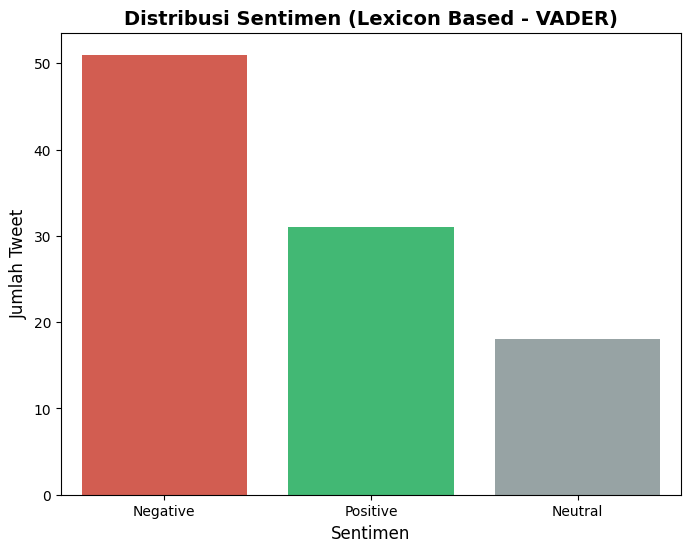

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df_subset, palette=['#e74c3c', '#2ecc71', '#95a5a6'], order=['Negative', 'Positive', 'Neutral'])
plt.title('Distribusi Sentimen (Lexicon Based - VADER)', fontsize=14, fontweight='bold')
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)
plt.show()
